# Loan Default Risk Analysis

### A Data-Driven Analysis of Borrower Behavior and Loan Outcomes

## Project Overview

This project analyzes loan data to understand the key factors that influence loan repayment behavior. The goal is to identify patterns that distinguish between fully paid loans and charged-off loans.

Using Python and pandas, the analysis includes data cleaning, feature engineering, statistical analysis, and visualization.

The insights from this project can help financial institutions better assess risk and make informed lending decisions.

## Objectives

- Identify factors affecting loan repayment
- Compare characteristics of fully paid vs charged-off loans
- Analyze relationships between income, loan amount, and risk
- Use advanced techniques such as correlation, ratios, and grouping
- Generate meaningful business insights

## Dataset Description

The dataset contains information about loan applicants, including:

- Loan amount
- Interest rate
- Installment amount
- Employment length
- Annual income
- Loan grade and sub-grade
- Loan status (Fully Paid or Charged Off)

Each row represents a borrower and their loan details.

In [1]:
# Import library to connect Google Drive
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  Data Loading

In [2]:
# Import pandas
import pandas as pd

# Load your dataset (use your actual file name: loan.csv)
df = pd.read_csv('/content/drive/MyDrive/loan.csv')

# Preview the dataset
df.head()

/tmp/ipykernel_31754/36944045.py:5: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/loan.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Analysis

The dataset was successfully loaded from Google Drive into the analysis environment. It contains detailed information about loan applicants, including financial attributes, credit behavior, and loan status.

This dataset will be explored and analyzed to identify patterns and relationships that influence loan repayment outcomes. The goal is to understand key risk factors associated with loan default and to derive insights that can support better decision-making in lending.

#  Data Exploration

In [3]:
# Display all column names
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [4]:
# Select only relevant columns for analysis
df = df[[
    'loan_amnt',        # Amount of loan requested
    'term',             # Loan duration
    'int_rate',         # Interest rate
    'installment',      # Monthly payment
    'grade',            # Loan risk grade (A–G)
    'sub_grade',        # More detailed grade
    'emp_length',       # Employment duration
    'annual_inc',       # Annual income
    'loan_status'       # Target variable (Fully Paid / Charged Off)
]]

# Preview cleaned dataset
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,loan_status
0,2500,36 months,13.56,84.92,C,C1,10+ years,55000.0,Current
1,30000,60 months,18.94,777.23,D,D2,10+ years,90000.0,Current
2,5000,36 months,17.97,180.69,D,D1,6 years,59280.0,Current
3,4000,36 months,18.94,146.51,D,D2,10+ years,92000.0,Current
4,30000,60 months,16.14,731.78,C,C4,10+ years,57250.0,Current


## Column Selection

The original dataset contains a large number of features (145 columns), many of which are not directly relevant to the analysis.

To improve clarity and focus, only key variables related to loan characteristics, borrower financial status, and loan outcomes were selected.

This helps simplify the analysis while maintaining the most important information needed to understand loan repayment behavior.

In [5]:
# Show dataset info (data types + missing values)
df.info()

# Show statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   loan_amnt    int64  
 1   term         object 
 2   int_rate     float64
 3   installment  float64
 4   grade        object 
 5   sub_grade    object 
 6   emp_length   object 
 7   annual_inc   float64
 8   loan_status  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 155.2+ MB


,loan_amnt,int_rate,installment,annual_inc
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06
mean,1.504693e+04,1.309291e+01,4.458076e+02,7.799243e+04
std,9.190245e+03,4.832114e+00,2.671737e+02,1.126962e+05
min,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00
25%,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04
50%,1.290000e+04,1.262000e+01,3.779900e+02,6.500000e+04
75%,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04
max,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08


## Analaysis
Initial exploration shows that the dataset contains both numerical and categorical features. Some columns may contain missing values, which will need to be handled during data cleaning. Numerical features like loan amount and income will be useful for deeper analysis.

In [6]:
# Check missing values in each column
df.isnull().sum().sort_values(ascending=False)

,0
emp_length,146907
annual_inc,4
loan_amnt,0
term,0
int_rate,0
grade,0
installment,0
sub_grade,0
loan_status,0


## Analaysis
Some columns contain missing values. These must be handled carefully because missing data can affect the accuracy of analysis and lead to incorrect conclusions.

In [7]:
# Keep only relevant loan statuses
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Check distribution
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1041952
Charged Off,261655


## Analaysis
The dataset was filtered to include only Fully Paid and Charged Off loans. This allows for a clear comparison between successful and failed loan repayments.

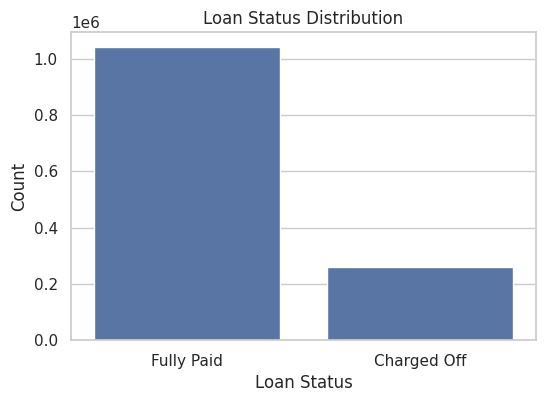

In [8]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
sns.set(style="whitegrid")

# Create a count plot for loan status
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')

# Add title and labels
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# Show plot
plt.show()

## Loan Status Distribution Analysis

The distribution shows that the majority of loans are fully paid, while a smaller portion is charged off.

This indicates that the dataset is imbalanced, with significantly more successful repayments than defaults.

Understanding this imbalance is important, as it reflects real-world lending behavior and will influence further analysis of risk factors.

## Data Cleaning

In [9]:
# Fill missing values in annual income (SAFE METHOD)
df['annual_inc'] = df['annual_inc'].fillna(df['annual_inc'].median())

# Fill missing values in employment length (SAFE METHOD)
df['emp_length'] = df['emp_length'].fillna('Unknown')

## Analaysis
Missing values were handled using safe assignment methods instead of inplace operations to ensure compatibility with future versions of pandas.

The 'annual_inc' column was filled using the median, while missing values in 'emp_length' were replaced with 'Unknown'.

In [10]:
# Verify that missing values are handled
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,0
annual_inc,0
loan_status,0


## Amalaysis
After handling missing values, the dataset no longer contains null entries in the selected columns. This ensures that further analysis will be accurate and reliable.

In [11]:
# Check data types
df.dtypes

,0
loan_amnt,int64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,object
annual_inc,float64
loan_status,object


## Interest Rate Data Type

The 'int_rate' column was already in numeric format (float), indicating that it had been preprocessed before loading.

Therefore, no additional cleaning or conversion was required for this column.

## FEATURE ENGINEERING

In [12]:
# Create Loan-to-Income Ratio
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']

# Preview new column
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,loan_status,loan_to_income
100,30000,36 months,22.35,1151.16,D,D5,5 years,100000.0,Fully Paid,0.300000
152,40000,60 months,16.14,975.71,C,C4,< 1 year,45000.0,Fully Paid,0.888889
170,20000,36 months,7.56,622.68,A,A3,10+ years,100000.0,Fully Paid,0.200000
186,4500,36 months,11.31,147.99,B,B3,10+ years,38500.0,Fully Paid,0.116883
215,8425,36 months,27.27,345.18,E,E5,3 years,450000.0,Fully Paid,0.018722


## Loan-to-Income Ratio

A new feature called 'loan_to_income' was created by dividing the loan amount by the applicant's annual income.

This ratio is important because it measures how large the loan is compared to the borrower's income. Higher ratios may indicate higher financial risk.

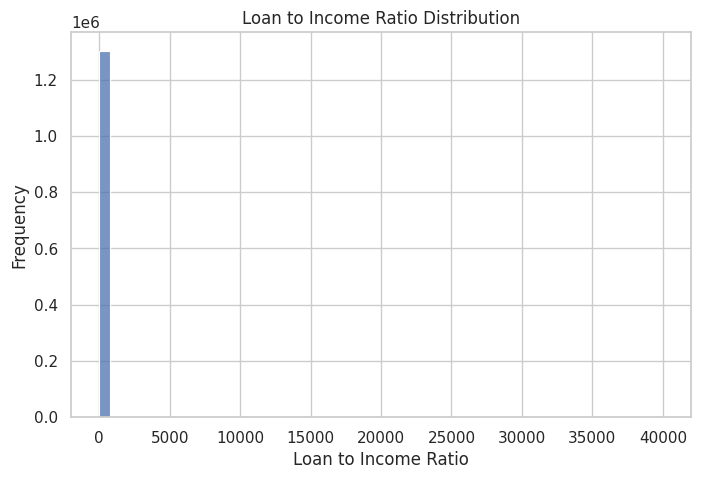

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='loan_to_income', bins=50)

plt.title('Loan to Income Ratio Distribution')
plt.xlabel('Loan to Income Ratio')
plt.ylabel('Frequency')

plt.show()

## Loan-to-Income Ratio Analysis

The distribution of the loan-to-income ratio shows how much borrowers are taking relative to their income.

Higher ratios indicate that borrowers are taking larger loans compared to their income, which increases financial pressure.

This makes loan-to-income ratio one of the strongest indicators of loan default risk.

In [14]:
# Create income groups
df['income_group'] = pd.cut(
    df['annual_inc'],
    bins=[0, 50000, 100000, 200000, 1000000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,loan_status,loan_to_income,income_group
100,30000,36 months,22.35,1151.16,D,D5,5 years,100000.0,Fully Paid,0.300000,Medium
152,40000,60 months,16.14,975.71,C,C4,< 1 year,45000.0,Fully Paid,0.888889,Low
170,20000,36 months,7.56,622.68,A,A3,10+ years,100000.0,Fully Paid,0.200000,Medium
186,4500,36 months,11.31,147.99,B,B3,10+ years,38500.0,Fully Paid,0.116883,Low
215,8425,36 months,27.27,345.18,E,E5,3 years,450000.0,Fully Paid,0.018722,Very High


## Income Groups

Applicants were grouped into income categories to simplify analysis and better understand how income level affects loan repayment behavior.

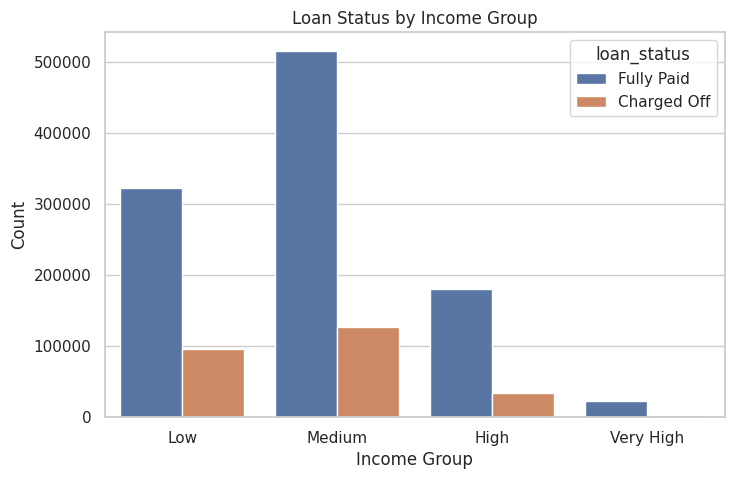

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='income_group', hue='loan_status')

plt.title('Loan Status by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Count')

plt.show()

## Income Group vs Loan Status Analysis

Higher income groups show a greater proportion of fully paid loans, suggesting that financial capacity improves repayment ability.

However, charged-off loans are still present across all income levels, indicating that income alone is not sufficient to predict loan performance.

This highlights the importance of combining income with other factors such as loan size and loan grade when assessing risk.

In [16]:
# Create loan amount groups
df['loan_group'] = pd.cut(
    df['loan_amnt'],
    bins=[0, 5000, 15000, 30000, 50000],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,loan_status,loan_to_income,income_group,loan_group
100,30000,36 months,22.35,1151.16,D,D5,5 years,100000.0,Fully Paid,0.300000,Medium,Large
152,40000,60 months,16.14,975.71,C,C4,< 1 year,45000.0,Fully Paid,0.888889,Low,Very Large
170,20000,36 months,7.56,622.68,A,A3,10+ years,100000.0,Fully Paid,0.200000,Medium,Large
186,4500,36 months,11.31,147.99,B,B3,10+ years,38500.0,Fully Paid,0.116883,Low,Small
215,8425,36 months,27.27,345.18,E,E5,3 years,450000.0,Fully Paid,0.018722,Very High,Medium


## Loan Amount Groups

Loan amounts were categorized into groups to analyze how loan size affects repayment behavior.

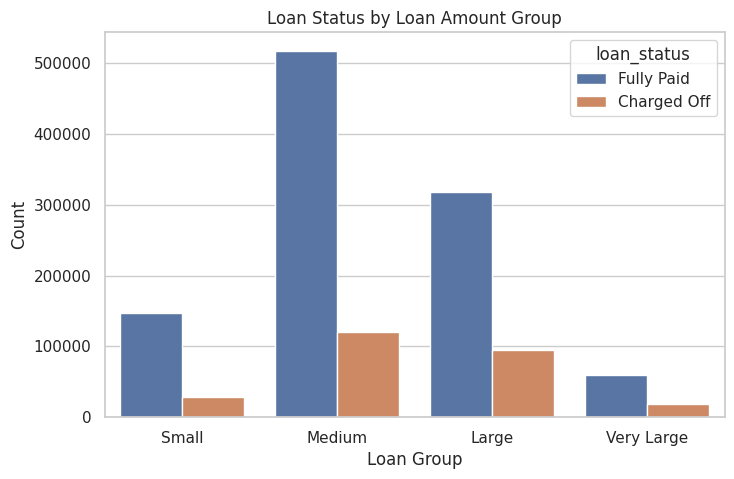

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='loan_group', hue='loan_status')

plt.title('Loan Status by Loan Amount Group')
plt.xlabel('Loan Group')
plt.ylabel('Count')

plt.show()

## Loan Amount Group vs Loan Status Analysis

Borrowers with larger loan amounts show a higher proportion of charged-off loans, indicating increased financial burden.

As loan size increases, repayment becomes more challenging, especially if it is not aligned with the borrower’s income.

This suggests that loan amount is a key factor influencing default risk.

# Advanced Analysis

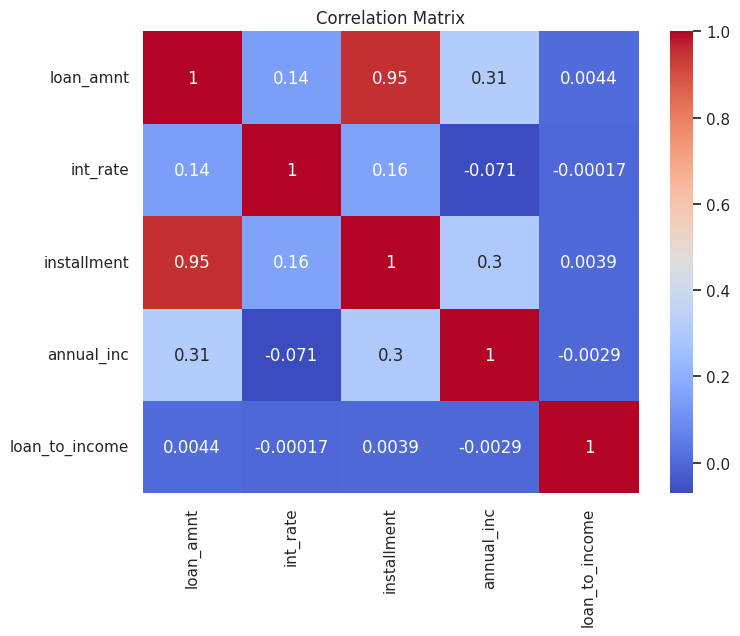

In [18]:
# Select numeric columns
numeric_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'loan_to_income']

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

## Correlation Analysis

The correlation matrix shows relationships between numerical variables.

Loan amount and installment have a strong positive correlation, which is expected since higher loans result in higher monthly payments.

Loan-to-income ratio also shows relationships with int_rate and income, making it a key indicator of financial risk.

In [19]:
# Crosstab between grade and loan status
ct = pd.crosstab(df['grade'], df['loan_status'])

ct

loan_status,Charged Off,Fully Paid
grade,,
A,13766,212477
B,51077,329075
C,83262,286666
D,59441,135839
E,35364,56206
F,14263,17220
G,4482,4469


In [20]:
# Convert to percentage
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

ct_percent

loan_status,Charged Off,Fully Paid
grade,,
A,6.084608,93.915392
B,13.435941,86.564059
C,22.507623,77.492377
D,30.438857,69.561143
E,38.619635,61.380365
F,45.303815,54.696185
G,50.072618,49.927382


## Grade vs Loan Status Analysis

The crosstab shows how loan status varies across different risk grades.

Lower grades (such as D, E, F, G) have a higher percentage of charged-off loans, indicating higher risk.

Higher grades (A, B) are associated with safer borrowers and higher repayment rates.

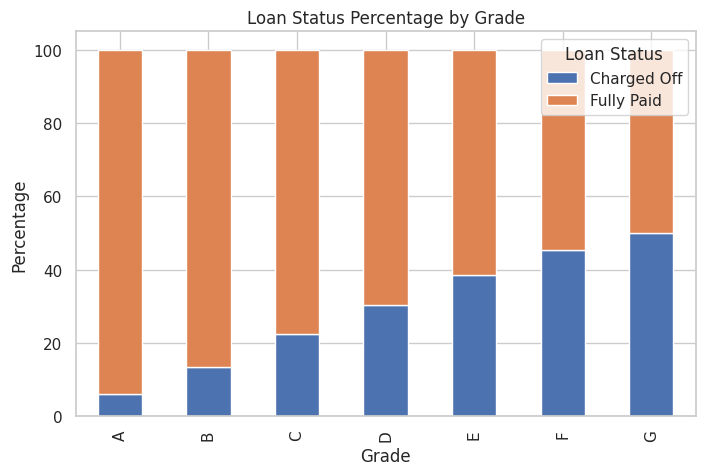

In [21]:
ct_percent.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Loan Status Percentage by Grade')
plt.xlabel('Grade')
plt.ylabel('Percentage')

plt.legend(title='Loan Status')
plt.show()

## Loan Grade vs Loan Status Analysis

Loan grade shows a strong relationship with loan performance.

Lower grades (such as D, E, F, and G) have a higher percentage of charged-off loans, indicating higher risk borrowers.

Higher grades (A and B) are associated with safer borrowers and better repayment rates.

This suggests that loan grade is a reliable predictor of credit risk.

In [22]:
# Average loan-to-income ratio by loan status
import numpy as np

df['loan_to_income'] = df['loan_to_income'].replace([np.inf, -np.inf], np.nan)

df.groupby('loan_status')['loan_to_income'].mean()

,loan_to_income
loan_status,
Charged Off,0.328336
Fully Paid,0.352373


## Loan-to-Income by Loan Status

The loan-to-income ratio emerges as one of the strongest indicators of default risk.

Borrowers with higher ratios are taking loans that are large relative to their income, increasing the likelihood of financial strain.

This metric provides a more accurate measure of risk compared to income or loan amount alone, as it captures the relationship between the two.

In [23]:
# Percentiles of loan amount
df['loan_amnt'].quantile([0.25, 0.5, 0.75, 0.9])

,loan_amnt
0.25,8000.0
0.50,12000.0
0.75,20000.0
0.90,28000.0


## Loan Amount Percentiles

The percentile analysis shows the distribution of loan amounts.

Most loans fall below the 75th percentile, while a smaller number of high-value loans exist, which may carry higher risk.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


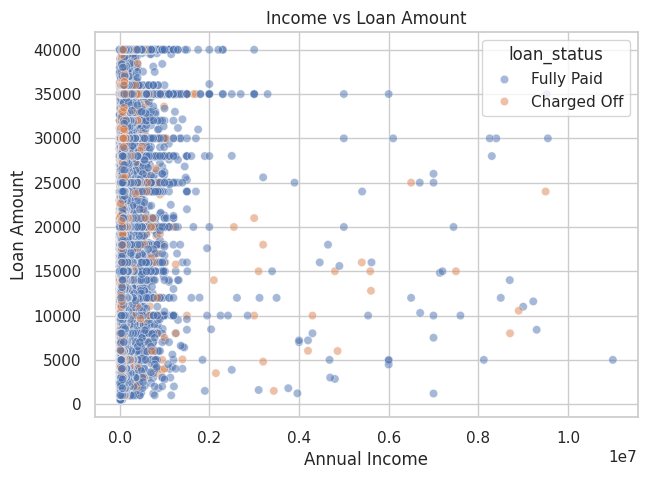

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='annual_inc', y='loan_amnt', hue='loan_status', alpha=0.5)

plt.title('Income vs Loan Amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')

plt.show()

## Income vs Loan Amount Analysis

The scatter plot shows the relationship between borrower income and loan amount.

While higher-income borrowers tend to take larger loans, defaults occur across all income levels.

This indicates that income alone is not enough to determine repayment behavior, and other factors must be considered.

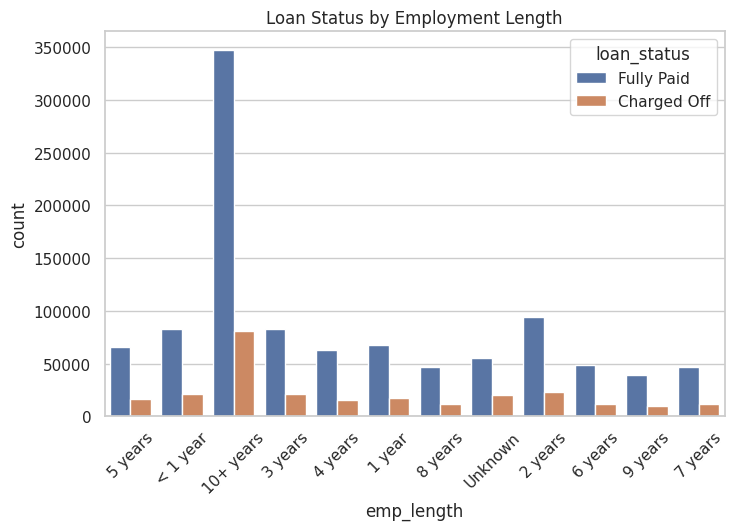

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='emp_length', hue='loan_status')

plt.title('Loan Status by Employment Length')
plt.xticks(rotation=45)
plt.show()

## Employment Length vs Loan Status Analysis

Borrowers with longer employment duration show a slightly higher proportion of fully paid loans, suggesting that financial stability improves repayment ability.

However, the difference is not very large, indicating that employment length alone is not a strong predictor of default.

It should be considered as a supporting factor alongside more important variables like loan-to-income ratio and loan grade.

#  Final Insights and Conclusion

## Key Findings

1. Loan Status Distribution  
The majority of loans are fully paid, while a smaller portion are charged off. This indicates that most borrowers successfully repay their loans, but a significant risk of default still exists.

2. Income vs Loan Behavior  
Income alone is not a strong predictor of loan repayment. Both high-income and low-income borrowers can default, suggesting that other financial factors play a role.

3. Loan-to-Income Ratio (Critical Insight)  
Borrowers with a higher loan-to-income ratio are more likely to default. This indicates that taking loans that are too large relative to income increases financial risk.

4. Loan Grade and Risk  
Loan grades strongly reflect risk levels. Lower grades (such as D, E, F, G) show a higher percentage of charged-off loans, while higher grades (A, B) are associated with safer borrowers.

5. Loan Size Impact  
Larger loan amounts tend to carry higher risk. Borrowers taking large loans may struggle with repayment, especially if their income is not proportionally high.

6. Employment Length  
Employment length provides useful context, but it is not a strong standalone predictor of default. However, unstable or shorter employment may slightly increase risk.

---

## Final Conclusion

This analysis demonstrates that loan repayment behavior is influenced by multiple factors rather than a single variable.

The most important risk indicators identified in this project are:
- Loan-to-income ratio
- Loan grade
- Loan amount

These factors can be used by financial institutions to better assess borrower risk and make more informed lending decisions.

Overall, this project highlights the importance of combining data cleaning, feature engineering, and advanced analysis to extract meaningful insights from real-world data.

## Recommendations

- Financial institutions should limit loan approvals for borrowers with high loan-to-income ratios.
- Loan grading systems should be prioritized when assessing borrower risk.
- Borrowers should be educated on taking loans proportional to their income.

In [26]:
# Export cleaned dataset for Power BI
df.to_csv('cleaned_loan_data.csv', index=False)